<a href="https://colab.research.google.com/github/AzizAbdelhamid/grovers-algorithm-qiskit/blob/main/grover_tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Grover's Search Algorithm in Qiskit
An interactive walkthrough demonstrating 3-qubit amplitude amplification for marked state $|101\rangle$.

In [ ]:
# Install dependencies for Google Colab runtime
!pip install qiskit qiskit-aer matplotlib pylatexenc --quiet

import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator

print("Environment setup complete! Qiskit is ready.")

Environment setup complete! Qiskit is ready.


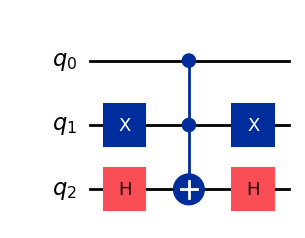

In [ ]:
def create_oracle(target: str = "101") -> QuantumCircuit:
    """Builds a phase oracle for a 3-qubit marked state."""
    qc = QuantumCircuit(3, name="Oracle")

    # Flip bits that are '0' so target aligns with |111>
    for i, bit in enumerate(reversed(target)):
        if bit == '0':
            qc.x(i)

    # Multi-controlled Z gate using Hadamard sandwich around MCX
    qc.h(2)
    qc.mcx([0, 1], 2)
    qc.h(2)

    # Revert X gates
    for i, bit in enumerate(reversed(target)):
        if bit == '0':
            qc.x(i)

    return qc

oracle = create_oracle("101")
oracle.draw('mpl')

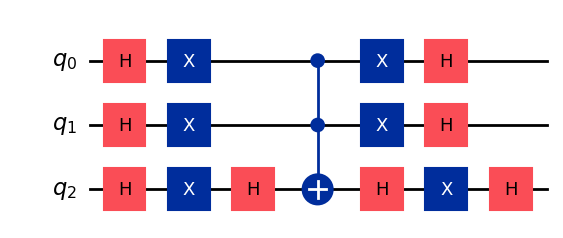

In [ ]:
def create_diffuser() -> QuantumCircuit:
    """Builds the 3-qubit Grover Diffuser (Inversion about the mean)."""
    qc = QuantumCircuit(3, name="Diffuser")

    qc.h([0, 1, 2])
    qc.x([0, 1, 2])

    # Phase shift
    qc.h(2)
    qc.mcx([0, 1], 2)
    qc.h(2)

    qc.x([0, 1, 2])
    qc.h([0, 1, 2])

    return qc

diffuser = create_diffuser()
diffuser.draw('mpl')

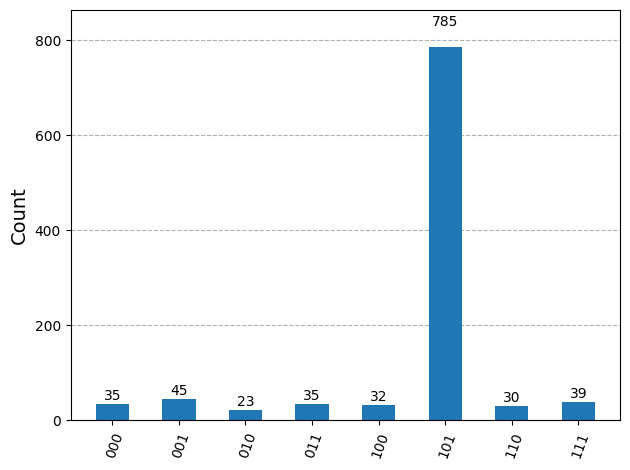

In [ ]:
# 1. Initialize Circuit
grover_circuit = QuantumCircuit(3, 3)

# 2. Superposition
grover_circuit.h([0, 1, 2])
grover_circuit.barrier()

# 3. Apply Oracle + Diffuser (1 iteration optimal for N=8, M=1)
grover_circuit.compose(oracle, inplace=True)
grover_circuit.barrier()
grover_circuit.compose(diffuser, inplace=True)
grover_circuit.barrier()

# 4. Measurement
grover_circuit.measure([0, 1, 2], [0, 1, 2])

# 5. Run on AerSimulator
simulator = AerSimulator()
counts = simulator.run(grover_circuit, shots=1024).result().get_counts()

# Plot histogram showing probability amplification
plot_histogram(counts)